In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [2]:
import sklearn
from sklearn.decomposition import PCA

In [37]:
header = "D:/K_sunada/result/CDY153/"
current = "/2023-12-25/2023-12-25T173939_242db88a-cw_JPA_current_vs_freq"
cuerrnt = "/2023-12-27/2023-12-27T153455_0c6a30fa-cw_JPA_current_vs_freq"
dd = datadict_from_hdf5(header + current +"/data")

In [29]:
current1 = "/2023-12-27/2023-12-27T141626_156ab6b2-cw_JPA_current_vs_freq"
dd1 = datadict_from_hdf5(header + current1 +"/data")

In [4]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [38]:
x = np.unique(dd['current']['values'])
y = np.unique(dd['frequency']['values'])
z = dd['s11']['values']/dd['s11']['values'][-1]

In [30]:
x1 = np.unique(dd1['current']['values'])
y1 = np.unique(dd1['frequency']['values'])
z1 = dd1['s11']['values']/dd1['s11']['values'][-1]

C:\Users\qipe\AppData\Local\Temp\ipykernel_15528\556086337.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('magma')


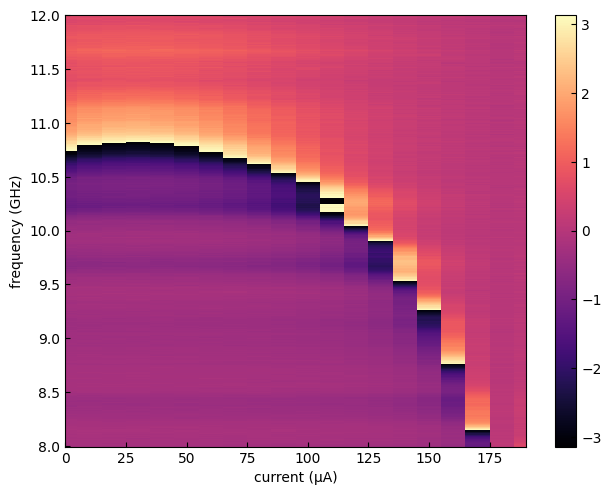

In [39]:
cm = plt.cm.get_cmap('magma')
fig= plt.figure()
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
ax = fig.add_axes((0.1, 0.1, 0.9, 0.9))
ax.set_xlabel("current (μA)")
ax.set_ylabel("frequency (GHz)")
ax.set_xlim(0, 190)

maingraph = ax.pcolormesh(x,y, np.angle(z).reshape(21, 401).T, vmin=min(np.unique(np.angle(z))), vmax=max(np.unique(np.angle(z))), cmap=cm, shading='auto')
plt.colorbar(maingraph)
plt.show()

C:\Users\qipe\AppData\Local\Temp\ipykernel_15528\1112019344.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('magma')


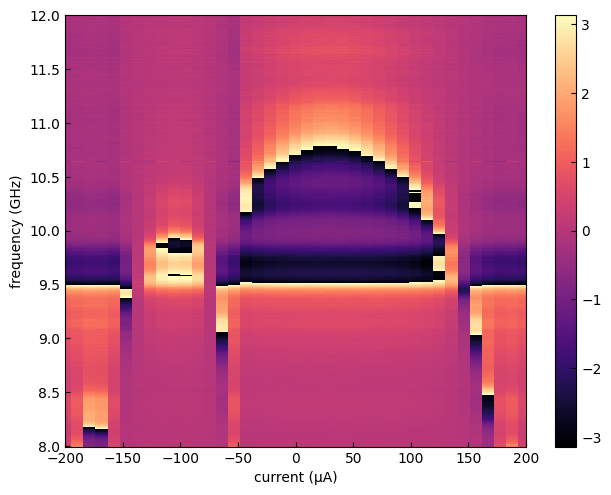

In [33]:
cm = plt.cm.get_cmap('magma')
fig= plt.figure()
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
ax = fig.add_axes((0.1, 0.1, 0.9, 0.9))
ax.set_xlabel("current (μA)")
ax.set_ylabel("frequency (GHz)")
ax.set_xlim(-200, 200)

maingraph = ax.pcolormesh(x1,y1, np.angle(z1).reshape(43, 401).T, vmin=min(np.unique(np.angle(z))), vmax=max(np.unique(np.angle(z))), cmap=cm, shading='auto')
plt.colorbar(maingraph)
plt.show()

In [7]:
def S11_resonator(freq, fc, ke, ki, a0, a1, Poff, ed):
    numer = 1j*(freq-fc)+(ke-ki)/2
    denom = 1j*(freq-fc)-(ke+ki)/2
    model = (numer/denom * (a0+a1*(freq-freq[0])) * np.exp(1j*(-Poff-ed*2*np.pi*freq))).conj()
    return model

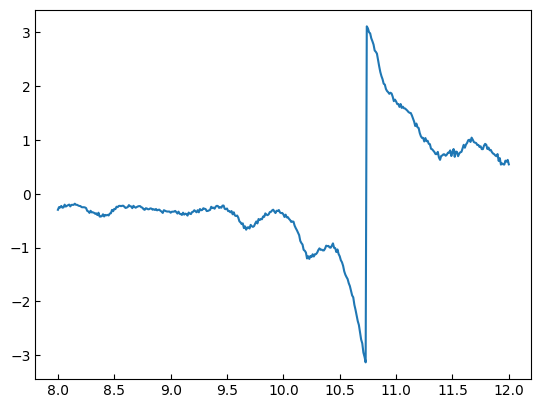

In [8]:
plt.plot(y, np.angle(z[0]))
plt.show()

In [9]:
par_ini = {
    'fc':11,
    'ke':0.1,
    'ki':0.0002,
    'a0':1,
    'a1':1,
    'Poff':np.pi/2,
    'ed':0,
}

par_min = {
    'fc':0,
    'ke':0,
    'ki':0,
    'a0':0,
    'a1':- np.inf,
    'Poff':- np.pi,
    'ed':- np.inf,
}

par_max = {
    'fc':np.inf,
    'ke':np.inf,
    'ki':np.inf,
    'a0':np.inf,
    'a1':np.inf,
    'Poff':np.pi,
    'ed':np.inf,
}

par_vary = {
    'fc':True,
    'ke':True,
    'ki':True,
    'a0':True,
    'a1':True,
    'Poff':True,
    'ed':True,
}

In [10]:
model = lmfit.Model(S11_resonator)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

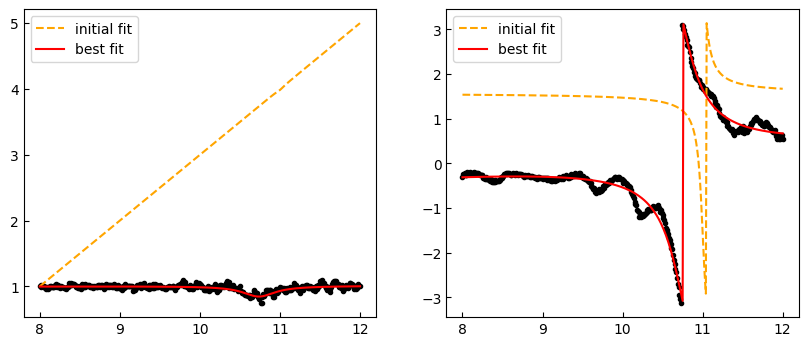

In [11]:
s11 = z[0]
res = model.fit(data = s11, params = params, freq = y)

fig, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(y, np.abs(s11), '.', color='k')
ax[0].plot(y, np.abs(res.init_fit), '--', label='initial fit', color='orange')
ax[0].plot(y, np.abs(res.best_fit), '-', label='best fit', color='red')
ax[0].legend()
ax[1].plot(y, np.angle(s11), '.', color='k')
ax[1].plot(y, np.angle(res.init_fit), '--', label='initial fit', color='orange')
ax[1].plot(y, np.angle(res.best_fit), '-', label='best fit', color='red')
ax[1].legend()


plt.show()
res

In [41]:
20*np.log10(7)

16.901960800285135

C:\Users\qipe\AppData\Local\Temp\ipykernel_5136\3407574840.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('Blues')


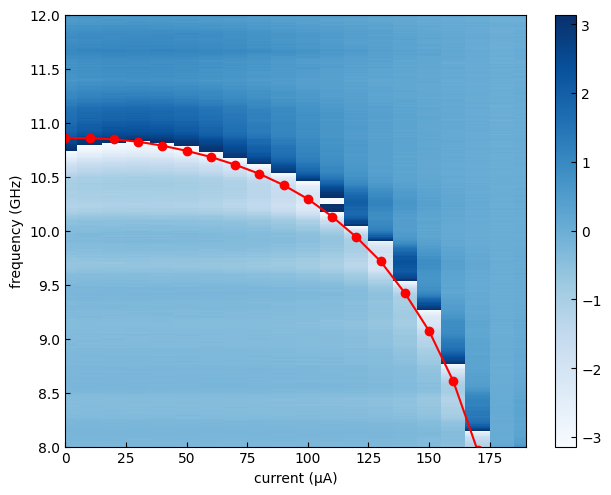

In [13]:
cm = plt.cm.get_cmap('Blues')
fig= plt.figure()
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
ax = fig.add_axes((0.1, 0.1, 0.9, 0.9))
ax.set_xlabel("current (μA)")
ax.set_ylabel("frequency (GHz)")
ax.set_xlim(0, 190)
ax.set_ylim(8.0, 12.0)

maingraph = ax.pcolormesh(x,y, np.angle(z).reshape(21, 401).T, vmin=min(np.unique(np.angle(z))), vmax=max(np.unique(np.angle(z))), cmap=cm, shading='auto')
plt.colorbar(maingraph)

fc = [10.8587745, 10.8550501, 10.8456669, 10.8231799, 10.7864414, 10.7383513, 10.6816157, 10.6103386, 10.5260210, 10.4210533, 10.2930179, 10.1303700, 9.93985631, 9.71551017, 9.42214628, 9.07045478, 8.60424930, 7.96394895]
plt.plot(x[0:18], fc, '-o',color='red')

plt.show()



In [14]:
data = "/2023-11-27/2023-11-27T161024_08bbc6b1-cw_JPA_gain_amp"
dd = datadict_from_hdf5(header + data +"/data")

ValueError: Specified file does not exist.

In [ ]:
s11 = dd["s11"]["values"]
freq =dd["frequency"]["values"]
Gain= 20 * np.log10(np.abs(s11))

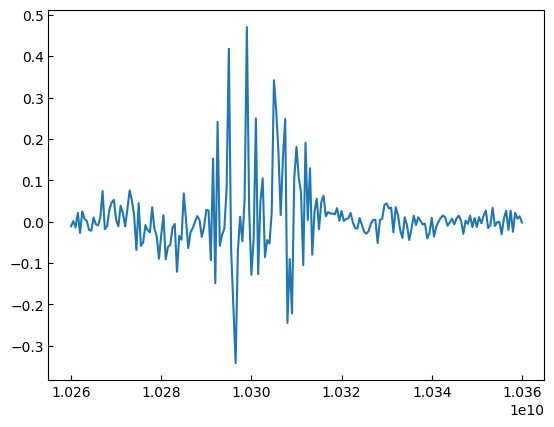

In [ ]:
plt.plot(freq, Gain)

JPA calibration

In [42]:
pump ="/2023-12-27/2023-12-27T162851_9570e0e8-cw_JPA_gain_amp"
dd = datadict_from_hdf5(header + pump +"/data")

In [43]:
dd

s11: (21, 201)
  ⌙ frequency (GHz): (21, 201)
  ⌙ amplitude (V): (21,)
s11_per_base: (21, 201)
  ⌙ frequency (GHz): (21, 201)
  ⌙ amplitude (V): (21,)

0.4


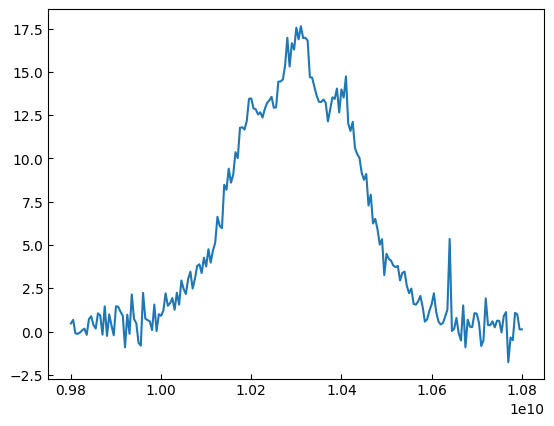

In [67]:
id = 0
x = dd['frequency']['values'][id]
y = dd['amplitude']['values'][id]
z = 20 * np.log10(np.abs(dd['s11_per_base']['values'][id]))
plt.plot(x, z)
print(y)

In [68]:
pump = "/2023-12-27/2023-12-27T165854_c7bb706a-cw_JPA_gain_amp" 
dd = datadict_from_hdf5(header + pump +"/data")

0.35


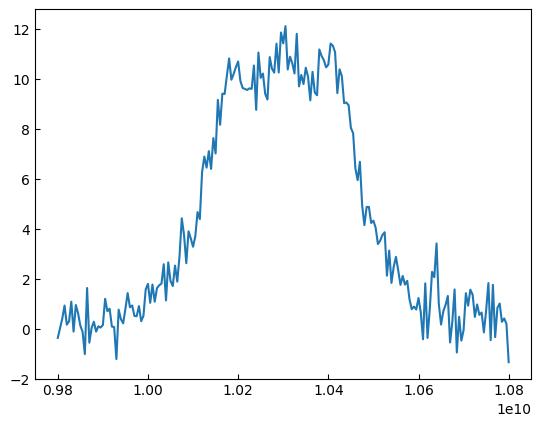

In [76]:
id = 15
x = dd['frequency']['values'][id]
y = dd['amplitude']['values'][id]
z = 20 * np.log10(np.abs(dd['s11_per_base']['values'][id]))
plt.plot(x, z)
print(y)